🎉 7参数 Corner 图已输出: corner_7param.pdf


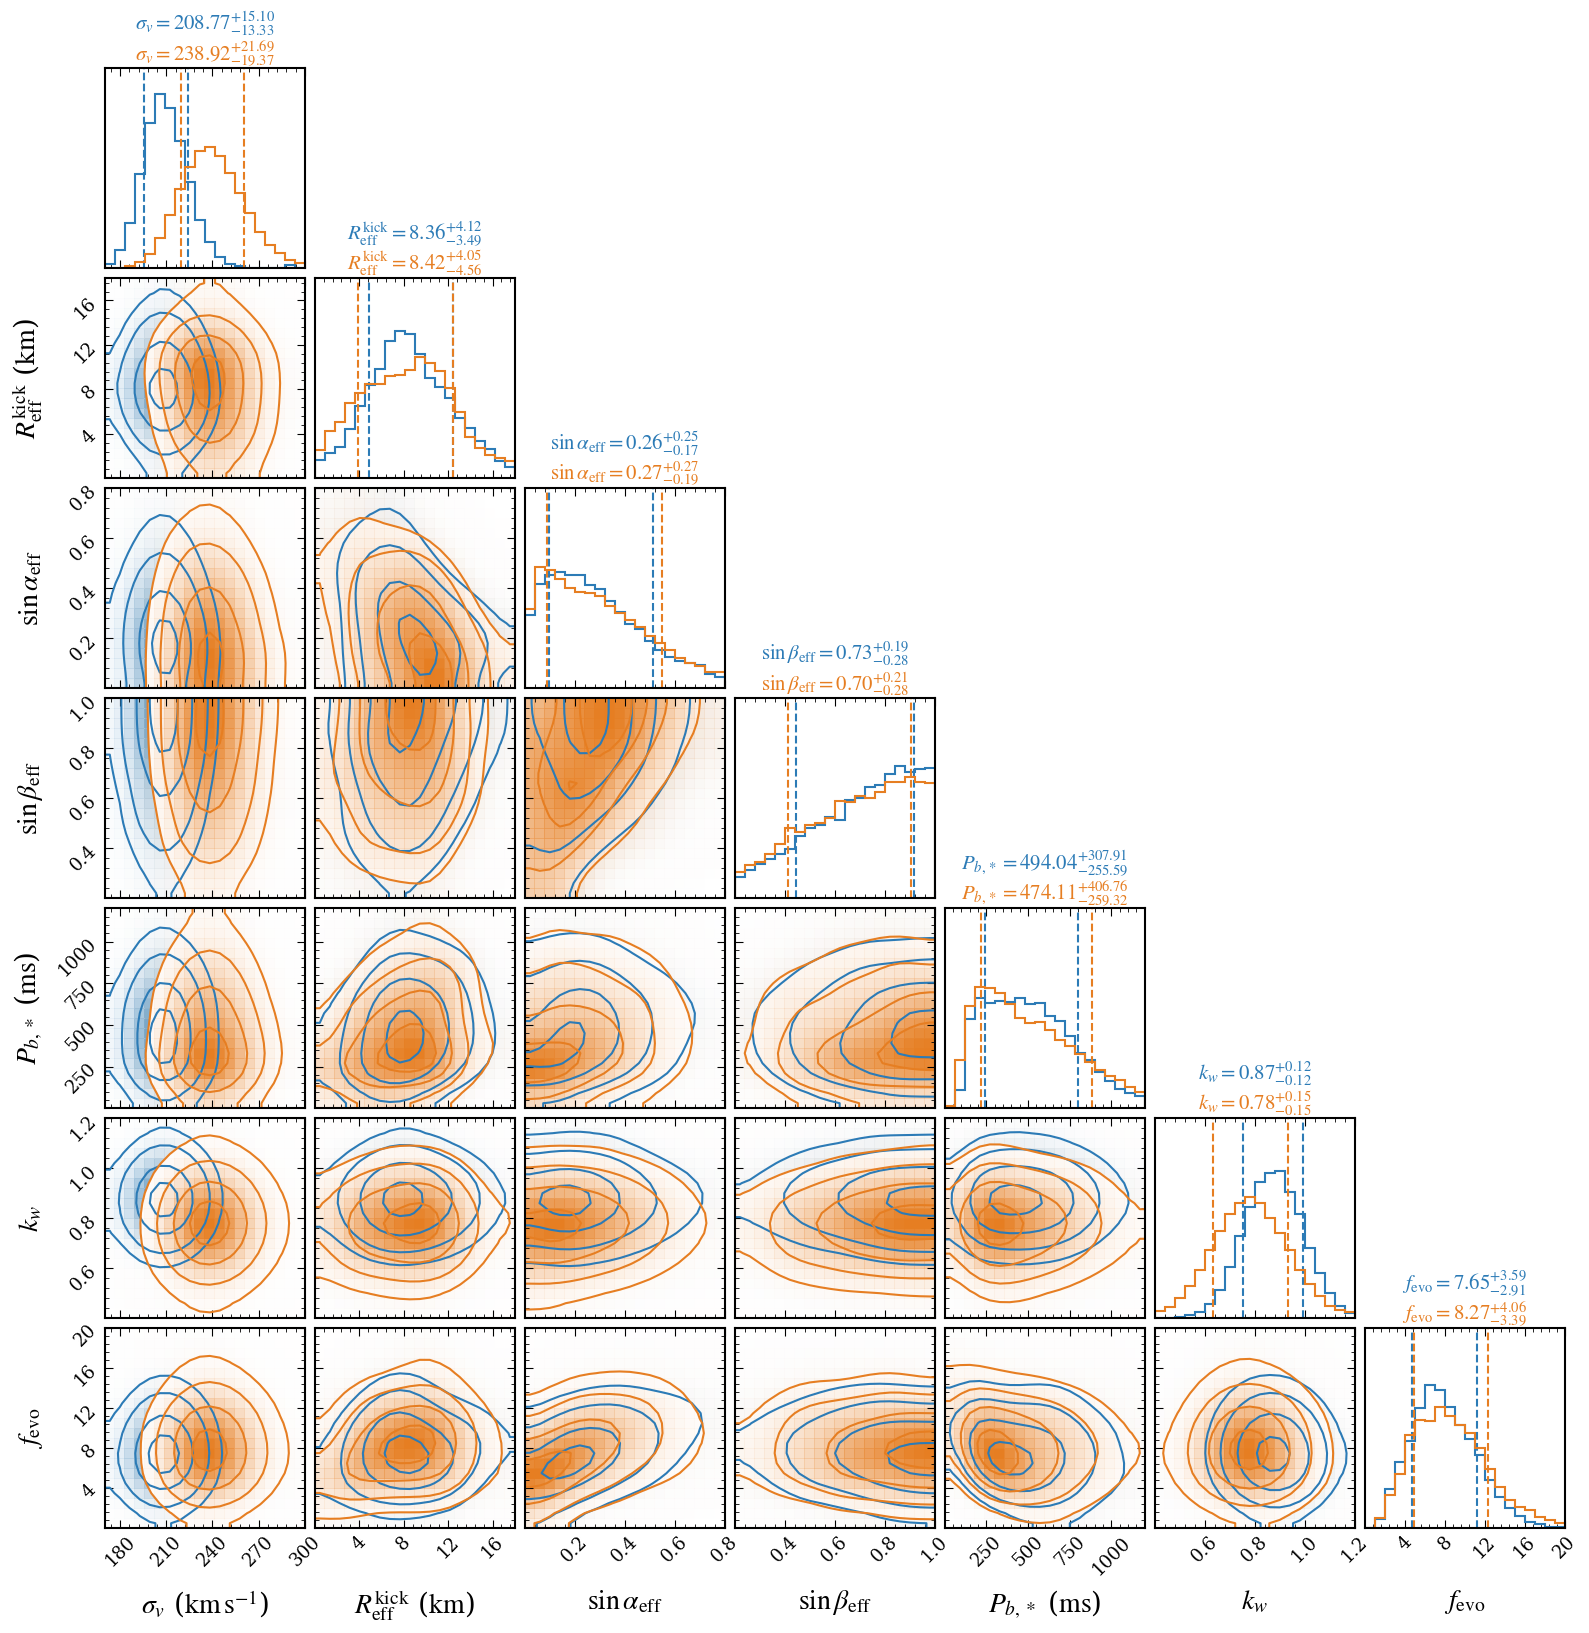

In [1]:
import pickle
import numpy as np
import corner
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
# --- 0. 文件路径配置 ---
path_all = "/home/lz/work/pulsar_kick_period/posterior_7param.pkl"
path_recycled = "/home/lz/work/pulsar_kick_period/posterior_young_7param.pkl"

# ============== plotting style for ApJ ==============
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIX Two Text", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "axes.labelsize": 20,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "axes.linewidth": 1.5,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

# --- 1. 数据加载函数 ---
def load_samples(path, target_columns):
    """从 pickle 文件中动态加载指定列名的样本"""
    try:
        with open(path, "rb") as f:
            data = pickle.load(f)
            
        cols = data["columns"]
        all_samples = data["samples"]
        
        # 动态获取这 7 个参数的索引
        indices = [cols.index(col) for col in target_columns]
        
        # 完美提取这 7 列并返回
        return all_samples[:, indices]
        
    except FileNotFoundError:
        print(f"❌ 错误：文件未找到 at {path}")
        return np.array([[np.nan]*len(target_columns)])
    except ValueError as e:
        print(f"❌ 错误：在 {path} 中找不到指定的列名。")
        print(f"👉 你的 pkl 文件里实际有的列名是: {cols}")
        print(f"👉 请修改代码里的 target_columns 列表，使其与上面打印的名字完全一致！")
        raise e

# 这里的名字必须和你 pkl 文件 data["columns"] 里的字符串一模一样！
target_columns = [
    "sigma_v",    # 对应 \sigma_{v}
    "R_eff",      # 对应 R_{eff}^{kick}
    "sin_alpha",  # 对应 \sin \alpha
    "sin_beta",   # 对应 \sin \beta
    "Pb_ms",      # 对应 P_{b,*} 
    "k_w",         # 对应 k_{w}
    "f_evo"       # 对应 f_{evo}
]

# 加载并提取样本
samples_all = load_samples(path_all, target_columns)       
samples_recycled = load_samples(path_recycled, target_columns) 

# --- 2. 定义绘图参数与标签 ---
# 使用专业和谐且色盲友好的对比色
# --- 2. 定义绘图参数与标签 ---
# === 完美复刻截图的“紫/青”高级感配色 ===
#color_all = "#9B76C7"       # 质感紫色 (对应截图大范围分布)
#color_all = "#51999E"  # 水墨青色 (对应截图小范围分布)
color_recycled = "#E67E22"   # 柔和橙色 (ColorBrewer OrRd_3[2]) - recycled
color_all = "#2C7BB6"     # 深蓝色 (ColorBrewer Blues_3[2]) - all
# 定义坐标轴标签 (底部和左侧显示的文字)
labels = [
    r"$\sigma_{v}$ ($\mathrm{km}\,\mathrm{s}^{-1}$)", 
    r"$R_{\mathrm{eff}}^{\mathrm{kick}}$ ($\mathrm{km}$)", 
    r"$\sin \alpha_{\mathrm{eff}}$", 
    r"$\sin \beta_{\mathrm{eff}}$", 
    r"$P_{b,*}$ ($\mathrm{ms}$)", 
    r"$k_{w}$", 
    r"$f_{\mathrm{evo}}$"
]

# 定义参数名称 (用于对角线顶部文字公式拼接)
param_names = [
    r"\sigma_{v}", 
    r"R_{\mathrm{eff}}^{\mathrm{kick}}", 
    r"\sin \alpha_{\mathrm{eff}}", 
    r"\sin \beta_{\mathrm{eff}}", 
    r"P_{b,*}", 
    r"k_{w}", 
    r"f_{\mathrm{evo}}"
]
ranges = [(170, 300), (0, 18),(0,0.8),(0.2,1),(0,1200),(0.4,1.2),(0,20)] 
n_params = len(labels)

# --- 3. 绘制 Corner 图 ---
# 绘制第一个数据集 (紫色)
fig = corner.corner(
    samples_all,
    labels=labels,
    color=color_all,
    #levels=(0.68, 0.95),      # <--- 核心修改：强制只画 68% 和 95% 两条等高线
    fill_contours=False,       
    plot_density=True,       # <--- 核心修改：关闭中心密度渐变，保持色块纯粹
    plot_datapoints=False, 
    show_titles=False,
    smooth=2,
    range=ranges,
    quantiles=[0.16, 0.84],
    # 给一维直方图加上黑色外边框
    hist_kwargs={"density": True, "color": color_all, "alpha": 1, "linewidth": 1.5},
    # 给二维等高线加上黑色描边
    contour_kwargs={"colors": color_all, "linewidths": 1.5, "linestyles": "solid"}
)

# 叠加第二个数据集 (青色)
corner.corner(
    samples_recycled,
    fig=fig,
    color=color_recycled,
    #levels=(0.68, 0.95),      # <--- 同样只保留两条等高线
    fill_contours=False,     
    plot_density=True,     
    plot_datapoints=False,  
    show_titles=False,
    smooth=2,
    range=ranges,
    quantiles=[0.16, 0.84],
    hist_kwargs={"density": True, "color": color_recycled, "alpha": 1,  "linewidth": 1.5},
    contour_kwargs={"colors": color_recycled, "linewidths": 1.5, "linestyles": "solid"}
)
# --- 4. 添加中位数和误差到对角线 ---
def median_err(samples):
    """计算中位数和 16th/84th 百分位误差"""
    q16, q50, q84 = np.percentile(samples, [16, 50, 84])
    return q50, q50 - q16, q84 - q50

# 获取所有的子图轴
axes = np.array(fig.axes).reshape(n_params, n_params)

for i in range(n_params):
    ax = axes[i, i]
    
    # 动态拉高 Y 轴上限 1.5 倍，防止文字和直方图重叠
    cur_ymin, cur_ymax = ax.get_ylim()
    ax.set_ylim(cur_ymin, cur_ymax * 1.5)

    # 计算 path_all (蓝色) 的中位数和误差
    m_all, lo_all, hi_all = median_err(samples_all[:, i])
    text_all = fr"${param_names[i]} = {m_all:.2f}^{{+{hi_all:.2f}}}_{{-{lo_all:.2f}}}$"
    
    # 计算 path_recycled (朱红色) 的中位数和误差
    m_recycled, lo_recycled, hi_recycled = median_err(samples_recycled[:, i])
    text_recycled = fr"${param_names[i]} = {m_recycled:.2f}^{{+{hi_recycled:.2f}}}_{{-{lo_recycled:.2f}}}$"
    
    # 在顶部添加蓝色文字
    ax.text(
        0.5, 1.15, text_all,
        color=color_all, fontsize=15,
        ha="center", va="bottom",
        transform=ax.transAxes
    )
    
    # 在蓝色文字下方添加朱红色文字
    ax.text(
        0.5, 1.0, text_recycled,
        color=color_recycled, fontsize=15,
        ha="center", va="bottom",
        transform=ax.transAxes
    )
# 遍历整个 corner 图里的所有子图（包括一维对角线和二维等高线图）
for ax in fig.axes:
    # 强制 X 轴和 Y 轴的主刻度之间划分为 10 个次刻度区间
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

# --- 5. 保存图片 ---
output_filename = "corner_7param.pdf"
fig.savefig(output_filename, dpi=300, bbox_inches="tight")
print(f"🎉 7参数 Corner 图已输出: {output_filename}")